# Semantic Bridge Analysis

## A TACC Computational Cookbook

**Developed by:** Texas Advanced Computing Center (TACC)  
**Institution:** The University of Texas at Austin  
**Contact:** [DSO@tacc.utexas.edu](mailto:DSO@tacc.utexas.edu)

---

### What This Cookbook Does

This tutorial demonstrates how to move from qualitative stakeholder narratives to quantitative scientific framing using natural language processing and lightweight machine learning.

By the end of the workflow, you will be able to:
1. discover themes in stakeholder documents
2. extract decision components such as goals, objectives, variables, and constraints
3. map those themes to scientific domains
4. connect plain-language concepts to scientific variables
5. generate outputs that support downstream decision analysis

Typical use cases include environmental planning, climate adaptation, infrastructure decision support, participatory modeling, and interdisciplinary problem framing.

### Prerequisites

- A TACC account and allocation, or another environment prepared from this repository
- Basic familiarity with Jupyter notebooks and Python
- A set of documents that describe a planning or decision problem

Supported inputs include `.txt`, `.json`, `.docx`, `.pdf`, and common image formats for OCR-based extraction.

### Quick Start

1. Run the setup cells to verify the managed environment.
2. Place source documents in `data/transcripts/`, or use the sample documents provided in this notebook.
3. Work through the topic discovery, science mapping, and decision-component extraction steps.
4. Review the generated figures, tables, and summary report in `outputs/`.

### Expected Outputs

- `*_topic_mappings.csv`: topics linked to scientific domains
- `*_components.csv`: extracted decision components
- `*_svo_mappings.csv`: semantic links to scientific variables
- `*_network.html`: interactive science-backbone visualization
- `*_report.md`: summary report for sharing and review

### Customization

- Update `science_backbone` to reflect your domain structure.
- Expand `svo_vocabulary` with variables relevant to your project.
- Adjust `n_topics` to match the size and diversity of your document set.
- Refine the decision-component extraction patterns for your context.

### Learn More

- [TACC Documentation](https://docs.tacc.utexas.edu)
- [TACC Training](https://learn.tacc.utexas.edu)
- [Science Gateways Community Institute](https://sciencegateways.org/)


## STEP 1: Setup

This notebook assumes the TACC environment has already been prepared by `run.sh`.

Step 1 is intentionally lightweight: it simply confirms that you are running inside the managed tutorial environment before loading the libraries used throughout the workflow.

In [1]:
# Import libraries and semantic-bridge helpers
from pathlib import Path

import pandas as pd
import spacy

from semantic_bridge_pipeline import (
    build_quick_reference,
    build_stats_table,
    build_summary_report,
    build_topic_summary,
    component_counts,
    component_table,
    create_network_figure,
    create_svo_mappings,
    deduplicate_svo_mappings,
    default_science_backbone,
    default_svo_vocabulary,
    discover_topics,
    ensure_data_directory,
    extract_decision_components,
    load_documents,
    map_topics_to_domains,
    plot_component_distribution,
    plot_svo_sunburst,
    plot_topic_distribution,
    preprocess_documents,
    preview_documents,
    svo_table,
    write_report,
    write_sample_documents,
    write_outputs_table,
)

nlp = spacy.load('en_core_web_sm')
print('✓ Libraries loaded successfully!')


✓ Libraries loaded successfully!


## Step 2: Prepare Input Data

In this step, you will assemble the document collection, or corpus, that describes the problem you want to analyze.

Typical examples include:
- Interview transcripts
- Meeting notes
- Stakeholder reports
- Grey literature reports
- Community narratives

**Supported formats:**
- `.txt` - Plain text files
- `.json` - JSON with text content (field: `text`, `content`, `body`, or `description`)
- `.docx` - Microsoft Word documents
- `.pdf` - PDFs with extractable text
- `.png` / `.jpg` / `.jpeg` / `.tif` / `.tiff` - Images for OCR extraction

**Corpus layout:**
- Put source files in `data/subsidence_groundwater_corpus/raw/`
- Put cleaned text files in `data/subsidence_groundwater_corpus/cleaned/` if you already have them
- The loader will prefer `cleaned/` when both versions exist and otherwise fall back to `raw/`

For this tutorial, you can either use your own files or run the next cell to generate sample documents in `raw/`.



In [2]:
# Resolve the tutorial data directory used throughout the notebook

def resolve_tutorial_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'semantic_bridge_cookbook.ipynb').exists():
            return candidate
        nested = candidate / 'DSO-Institute-2026' / 'Day-3' / 'Morning'
        if (nested / 'semantic_bridge_cookbook.ipynb').exists():
            return nested
    raise FileNotFoundError('Could not locate DSO-Institute-2026/Day-3/Morning')


tutorial_dir = resolve_tutorial_dir()
corpus_dir = ensure_data_directory(tutorial_dir / 'data' / 'subsidence_groundwater_corpus/')
data_dir = ensure_data_directory(corpus_dir / 'raw')
ensure_data_directory(corpus_dir / 'cleaned')

print(f'✓ Tutorial directory: {tutorial_dir}')
print(f'✓ Corpus directory: {corpus_dir}')
print(f'  Add source files to: {data_dir}')
print(f'  Optional cleaned text directory: {corpus_dir / "cleaned"}')



✓ Tutorial directory: /Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning
✓ Corpus directory: /Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus
  Add source files to: /Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus/raw
  Optional cleaned text directory: /Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus/cleaned


In [3]:
# Generate sample transcript documents for the tutorial
sample_transcripts = write_sample_documents(data_dir)

total_words = sum(len(content.split()) for content in sample_transcripts.values())
for filename in sample_transcripts:
    print(f'✓ Created: {filename}')

print(f'\n✓ Created {len(sample_transcripts)} sample documents in {data_dir}')
print(f'  Total words: {total_words}')



✓ Created: interview_001.txt
✓ Created: interview_002.txt
✓ Created: meeting_notes_001.txt
✓ Created: stakeholder_report.txt

✓ Created 4 sample documents in /Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus/raw
  Total words: 851


In [4]:
# Load documents from the corpus directories
transcripts = load_documents(corpus_dir)

print(f'✓ Loaded {len(transcripts)} documents:')
for filename in transcripts:
    print(f'  - {filename}')



invalid pdf header: b'<!-- '
EOF marker not found
invalid pdf header: b'<!-- '
EOF marker not found


Skipping region-h-water-plan-2021.pdf: Stream has ended unexpectedly
Skipping texas-state-water-plan-2022.pdf: Stream has ended unexpectedly
✓ Loaded 11 documents:
  - beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  - city-of-houston-2019-water-conservation-plan.pdf
  - harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf
  - texas-administrative-code-groundwater.txt
  - texas-tribune-groundwater-pumping-on-gulf-coast-leads-to-subsidence.txt
  - texas-tribune-groundwater-rights-and-water-crisis.txt
  - usgs-houston-galveston-bay-area-texas-from-space-fact-sheet.pdf
  - interview_001.txt
  - interview_002.txt
  - meeting_notes_001.txt
  - stakeholder_report.txt


In [5]:
# Preview a short excerpt from each document
for preview in preview_documents(transcripts):
    print(f'\n{"=" * 60}')
    print(f"File: {preview['filename']}")
    print(f'{"=" * 60}')
    print(preview['preview'])



File: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
HYDROGEOLOGY OF GULF COAST AQUIFERS, 
HOUSTON-GALVESTON AREA, TEXAS 1 
C. W. Kreitler 2, E. Guevera 3, G. Granata 2, and D. McKalips 2 
ABSTRACT 
Aquifers in the Houston-Galveston area are composed pr...

File: city-of-houston-2019-water-conservation-plan.pdf
        
 
TABLE OF CONTENTS 
INTRODUCTION .................................................................................................................... 5 
REQUIRED WATER CONSERVATION PLAN CONT...

File: harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf
 
Regulatory Plan 
2013 
 
 
 
 
 
 
 
 
Harris-Galveston  
Subsidence District 
1660 West Bay Area Blvd. 
Friendswood, Texas 77546-2640 
(281) 486-1105 
www.subsidence.org 
 
 
 
Adopted:  January 9,...

File: texas-administrative-code-groundwater.txt
Site Has Moved
This Site Has Moved
You will be redirected shortly to the new site. If not, click the button below:
Go to New Site
© 

In [6]:
# Summarize the size of the document collection
stats_df = build_stats_table(transcripts)

print('✓ Transcript Statistics:\n')
print(stats_df.to_string(index=False))


✓ Transcript Statistics:

                                                                   File  Characters  Words  Sentences
     beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf       44200   6656        387
                       city-of-houston-2019-water-conservation-plan.pdf      103292  14780        578
  harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf       28767   4119        184
                              texas-administrative-code-groundwater.txt         183     35          3
texas-tribune-groundwater-pumping-on-gulf-coast-leads-to-subsidence.txt       25152   3750        137
                  texas-tribune-groundwater-rights-and-water-crisis.txt       60955   9087        448
        usgs-houston-galveston-bay-area-texas-from-space-fact-sheet.pdf       32629   4872        217
                                                      interview_001.txt        1250    182         12
                                                      in

## Step 2a: Configure Filler Words

Use this cell to remove transcript fillers or domain-specific words that would otherwise dominate the topic model.

Examples include hesitation words such as `um` and `uh`, or repeated interview artifacts such as speaker labels.


In [7]:
# Customize filler words to remove before topic discovery
CUSTOM_STOPWORDS = {
    'um',
    'uh',
    'like',
    'you',
    'know',
}

print('Custom filler-word list:')
print(sorted(CUSTOM_STOPWORDS))


Custom filler-word list:
['know', 'like', 'uh', 'um', 'you']


## Step 3: Discover Topics

**What is topic modeling?**

Topic modeling automatically identifies themes in a document collection by grouping together words that often appear in the same context.

For example, if words like `flooding`, `water`, and `drainage` frequently occur together, the model may identify a topic related to stormwater or hydrology.

**How it works:**
1. Break text into words
2. Find patterns of co-occurring words
3. Group related words into topics
4. Assign topics to documents

**Parameters used in this step:**
- `n_topics` - The number of topics the model will try to discover across the corpus. Increase it for more thematic detail; decrease it for broader themes.
- `max_vocabulary` - The maximum number of unique words or phrases the model is allowed to consider when building topics. This limits the feature space to the most informative terms after preprocessing.
- `top_words_display` - The number of top-weighted keywords to show when summarizing each topic in the notebook output.

**How to think about `max_vocabulary`:**
- A larger value allows the model to consider more distinct terms.
- A smaller value forces the model to focus on a tighter set of common or high-signal terms.
- If this value is too small, important concepts may be excluded.
- If it is too large, the model may include more noisy or low-value terms.

For small tutorial corpora, values around `100` are usually fine. Larger, more diverse corpora often benefit from higher values.



In [8]:
# Set topic-modeling parameters
n_topics = 5
max_vocabulary = 200
top_words_display = 12

print('Analysis Parameters:')
print(f'  • Number of topics: {n_topics}')
print(f'  • Vocabulary size: {max_vocabulary}')
print(f'  • Keywords per topic: {top_words_display}')


Analysis Parameters:
  • Number of topics: 5
  • Vocabulary size: 200
  • Keywords per topic: 12


In [9]:
# Preprocess the document collection for topic discovery
processed_docs, doc_names = preprocess_documents(
    transcripts,
    custom_stopwords=CUSTOM_STOPWORDS,
)

print('✓ Text preprocessing complete')
print(f'\nExample: {processed_docs[0][:150]}...')


✓ Text preprocessing complete

Example: hydrogeology of gulf coast aquifers houston galveston area texas c w kreitler e guevera g granata and d mckalips abstract aquifers in the houston galv...


In [10]:
# Discover topics across the document collection
print('Discovering topics...\n')

topic_results = discover_topics(
    processed_docs,
    n_topics=n_topics,
    max_vocabulary=max_vocabulary,
    topic_keyword_count=top_words_display,
    custom_stopwords=CUSTOM_STOPWORDS,
)

doc_topic_dist = topic_results['doc_topic_dist']
topics_info = topic_results['topics_info']
feature_names = topic_results['feature_names']

print(f"✓ Vocabulary: {len(feature_names)} terms")
print(f'✓ Discovered {n_topics} topics\n')
print('Topics Discovered:')
print('=' * 60)
for topic_data in topics_info.values():
    print(f"\n{topic_data['label']}")
    print(f"  Full keywords: {', '.join(topic_data['keywords'][:top_words_display])}")
print('\n' + '=' * 60)


Discovering topics...

✓ Vocabulary: 200 terms
✓ Discovered 5 topics

Topics Discovered:

Topic 1: groundwater, regulatory, water
  Full keywords: groundwater, regulatory, water, subsidence, said, quot, district, regulatory area, plan, permittee, class, regulatory plan

Topic 2: water, infrastructure, new
  Full keywords: water, infrastructure, new, implementation, city, state, residential, year, include, texas, houston, development

Topic 3: subsidence, houston, galveston
  Full keywords: subsidence, houston, galveston, area, bay, galveston bay, fig, water, interval, texas, ground water, ground

Topic 4: center, term, area
  Full keywords: center, term, area, long, development, time, areas, district, new, infrastructure, state, reduction

Topic 5: water, sand, infrastructure
  Full keywords: water, sand, infrastructure, alternative, future, texas, goals, implementation, said, groundwater, report, year



Creating topic distribution chart...



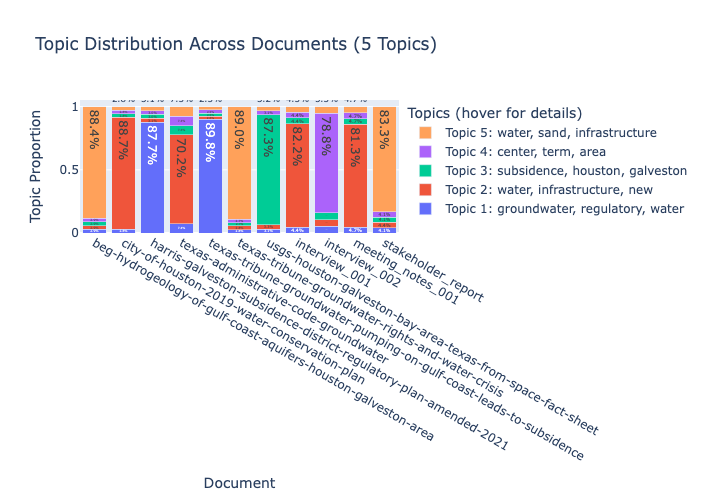

✓ Visualization complete!

Tip: change n_topics above and rerun Step 3 to compare topic structures.


In [11]:
# Visualize how topic emphasis changes across documents
print('Creating topic distribution chart...\n')

topic_df, fig = plot_topic_distribution(
    doc_topic_dist,
    doc_names,
    topics_info,
    n_topics=n_topics,
)
fig.show()

print('✓ Visualization complete!')
print('\nTip: change n_topics above and rerun Step 3 to compare topic structures.')


In [12]:
# Summarize the discovered topics in a table
summary_df = build_topic_summary(topics_info, doc_topic_dist, top_words_display)

print('\nTopic Summary:')
print('=' * 80)
print(summary_df.to_string(index=False))
print('=' * 80)



Topic Summary:
  Topic                                                                                                               Top Keywords Avg Coverage
Topic 1 groundwater, regulatory, water, subsidence, said, quot, district, regulatory area, plan, permittee, class, regulatory plan        19.6%
Topic 2           water, infrastructure, new, implementation, city, state, residential, year, include, texas, houston, development        31.5%
Topic 3                subsidence, houston, galveston, area, bay, galveston bay, fig, water, interval, texas, ground water, ground        11.6%
Topic 4                        center, term, area, long, development, time, areas, district, new, infrastructure, state, reduction        10.6%
Topic 5            water, sand, infrastructure, alternative, future, texas, goals, implementation, said, groundwater, report, year        26.7%


## Step 4: Map to the Science Backbone

This step connects the discovered topics to a simple scientific domain structure.

**What is the science backbone?**

Think of the science backbone as a lightweight hierarchy of domains and subdomains.

- Major domains: Environmental Science, Social Science, Engineering, and related fields
- Subdisciplines: Hydrology, Economics, Urban Planning, and others
- Specific problem areas: flood modeling, cost-benefit analysis, infrastructure resilience, and more

Mapping topics into this structure helps show which scientific fields are relevant to the stakeholder narratives.

In [13]:
# Set the output directory and case-study label
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
CASE_STUDY_NAME = 'community_analysis'

print(f'✓ Output directory: {OUTPUT_DIR}')
print(f'✓ Case study name: {CASE_STUDY_NAME}')


✓ Output directory: outputs
✓ Case study name: community_analysis


In [14]:
# Start from the default science backbone, then edit it for your project if needed
science_backbone = default_science_backbone()

print('Science Backbone Structure:')
print('=' * 60)
for domain, subdisciplines in science_backbone.items():
    print(f'\n{domain}:')
    for subdiscipline in subdisciplines:
        print(f'  • {subdiscipline}')
print('\n' + '=' * 60)


Science Backbone Structure:

Environmental Science:
  • Climate Science
  • Hydrology
  • Ecology
  • Coastal Systems

Physical Science:
  • Oceanography
  • Atmospheric Science
  • Geology
  • Geophysics

Social Science:
  • Economics
  • Urban Planning
  • Policy Analysis
  • Community Development

Engineering:
  • Civil Engineering
  • Infrastructure Design
  • Water Resources
  • Risk Management

Data Science:
  • Statistical Modeling
  • GIS Analysis
  • Machine Learning
  • Scenario Planning



In [15]:
# Map discovered topics into the science backbone
print('Mapping topics to domains...\n')
topic_mappings = map_topics_to_domains(topics_info)
mapping_df = pd.DataFrame(topic_mappings)

print('Topic-to-Domain Mappings:')
print('=' * 60)
for mapping in topic_mappings:
    print(f"\n{mapping['topic']}")
    print(f"  Keywords: {mapping['keywords']}")
    print(f"  Primary Domain: {mapping['primary_domain']}")
    if mapping['secondary_domain']:
        print(f"  Secondary Domain: {mapping['secondary_domain']}")
print('\n' + '=' * 60)


Mapping topics to domains...

Topic-to-Domain Mappings:

Topic 1
  Keywords: groundwater, regulatory, water, subsidence, said
  Primary Domain: Physical Science
  Secondary Domain: Environmental Science

Topic 2
  Keywords: water, infrastructure, new, implementation, city
  Primary Domain: Environmental Science
  Secondary Domain: Engineering

Topic 3
  Keywords: subsidence, houston, galveston, area, bay
  Primary Domain: Environmental Science
  Secondary Domain: Physical Science

Topic 4
  Keywords: center, term, area, long, development
  Primary Domain: Engineering

Topic 5
  Keywords: water, sand, infrastructure, alternative, future
  Primary Domain: Environmental Science
  Secondary Domain: Physical Science



Creating network visualization...



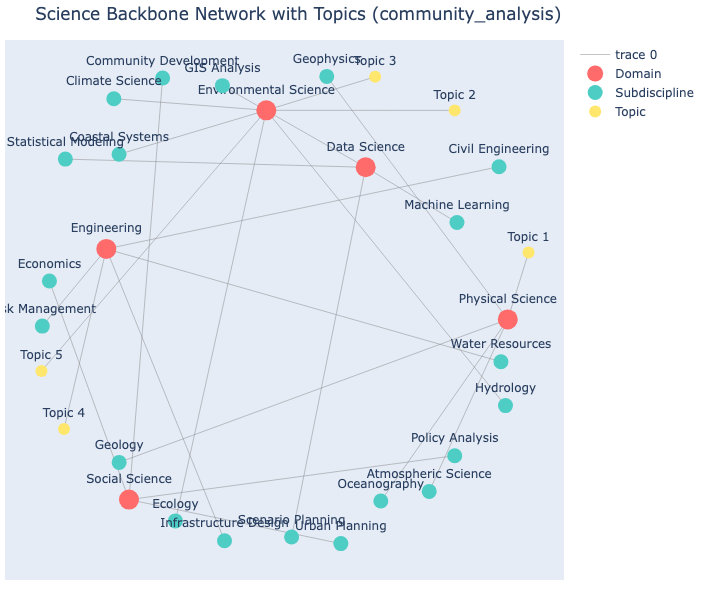

✓ Visualization complete!


In [16]:
# Visualize the relationship between domains, subdisciplines, and discovered topics
print('Creating network visualization...\n')

graph, network_fig = create_network_figure(
    science_backbone,
    topic_mappings,
    case_study_name=CASE_STUDY_NAME,
)
network_fig.show()

print('✓ Visualization complete!')


## Step 5: Extract Decision Components

Most decision problems include a common set of elements. In this step, the notebook looks for those elements directly in the text.

We focus on:
- Goals: What are we trying to achieve?
- Objectives: Specific, measurable aims
- Decision Variables: What can we control?
- Constraints: Limits that shape what is feasible
- Indicators: How do we measure success?

In [17]:
# Extract goals, objectives, variables, constraints, and indicators from the text
print('Extracting decision components...\n')
decision_components = extract_decision_components(transcripts, nlp)

print('Decision Components:')
print('=' * 60)
for component_type, items in decision_components.items():
    print(f'\n{component_type.upper()} ({len(items)} found):')
    for index, item in enumerate(items[:5], 1):
        print(f"  {index}. {item['text']}")
        print(f"     Source: {item['source']}")
print('\n' + '=' * 60)


Extracting decision components...

Decision Components:

GOALS (10 found):
  1. This 
stacking
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  2. a structural instability
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  3. major drainage
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  4. deltaic deposition
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  5. the same area
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf

OBJECTIVES (10 found):
  1. The principal objectives
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  2. this study
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  3. the distribution
     Source: beg-hydrogeology-of-gulf-coast-aquifers-houston-galveston-area.pdf
  4. structural 
elements
     Source: beg-hydrogeology-of-gulf-coast-aquifers-h

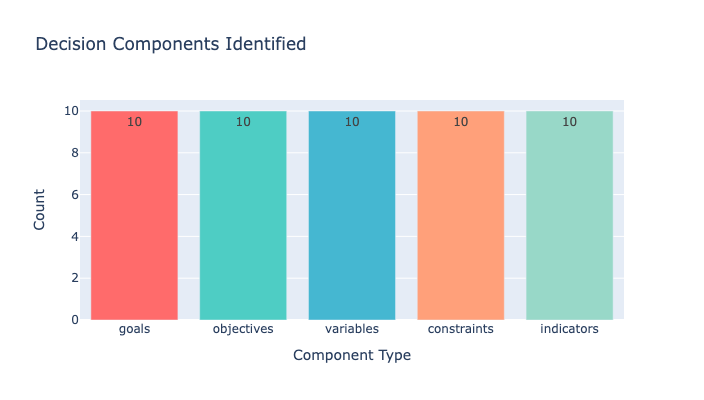

✓ Visualization complete!


In [18]:
# Visualize the balance of decision components found in the documents
component_counts_map = component_counts(decision_components)
component_fig = plot_component_distribution(component_counts_map)
component_fig.show()

print('✓ Visualization complete!')


In [19]:
# Convert extracted components into a reusable table
components_df = component_table(decision_components)

print(f'✓ Prepared {len(components_df)} component rows for export')
print('\nComponent breakdown:')
for component_type, count in component_counts_map.items():
    print(f'  • {component_type}: {count}')


✓ Prepared 50 component rows for export

Component breakdown:
  • goals: 10
  • objectives: 10
  • variables: 10
  • constraints: 10
  • indicators: 10


## Step 6: Link to Scientific Variables

**What are Scientific Variable Objects (SVOs)?**

An SVO is a standardized description of a measurable quantity.

It helps translate everyday language into scientific variables that can be observed, modeled, or retrieved from data systems.

Each SVO-style entry can include:
- Variable Name: What we measure (e.g., "Water Level")
- Units: How we measure it (e.g., "meters")
- Data Source: Where we get data (e.g., "USGS gauges")
- Standard Name: Scientific terminology

This step creates a translation layer between stakeholder language and measurable scientific concepts.

In [20]:
# Start from the default scientific-variable vocabulary, then customize it if needed
svo_vocabulary = default_svo_vocabulary()

print('Scientific Variable Object (SVO) Vocabulary:')
print('=' * 60)
for svo_name, svo_info in svo_vocabulary.items():
    print(f'\n{svo_name}:')
    print(f"  Standard: {svo_info['standard_name']}")
    print(f"  Units: {svo_info['units']}")
    print(f"  Domain: {svo_info['domain']}")
print('\n' + '=' * 60)


Scientific Variable Object (SVO) Vocabulary:

water_level:
  Standard: surface_water_elevation
  Units: meters
  Domain: Hydrology

precipitation:
  Standard: rainfall_rate
  Units: mm/hour
  Domain: Climate Science

groundwater_level:
  Standard: depth_to_groundwater
  Units: meters below surface
  Domain: Hydrology

sea_level:
  Standard: sea_surface_height
  Units: meters
  Domain: Oceanography

population_at_risk:
  Standard: exposed_population
  Units: count
  Domain: Social Science

economic_damage:
  Standard: flood_damage_cost
  Units: USD
  Domain: Economics

infrastructure_vulnerability:
  Standard: critical_infrastructure_exposure
  Units: index
  Domain: Engineering



In [21]:
# Link natural-language terms to scientific variables
print('Creating semantic links...\n')
svo_mappings = create_svo_mappings(transcripts, svo_vocabulary)
unique_mappings = deduplicate_svo_mappings(svo_mappings)
svo_df = svo_table(unique_mappings)

print(f'✓ Created {len(unique_mappings)} unique semantic links\n')
print('Sample Links (Natural Language → Scientific Variables):')
print('=' * 60)
for index, mapping in enumerate(unique_mappings[:6], 1):
    print(f"\n{index}. '{mapping['natural_language_term']}' →")
    print(f"   Variable: {mapping['scientific_variable']}")
    print(f"   Standard: {mapping['standard_name']}")
    print(f"   Units: {mapping['units']}")
    print(f"   Domain: {mapping['domain']}")
print('\n' + '=' * 60)


Creating semantic links...

✓ Created 24 unique semantic links

Sample Links (Natural Language → Scientific Variables):

1. 'water' →
   Variable: water_level
   Standard: surface_water_elevation
   Units: meters
   Domain: Hydrology

2. 'level' →
   Variable: water_level
   Standard: surface_water_elevation
   Units: meters
   Domain: Hydrology

3. 'flood' →
   Variable: water_level
   Standard: surface_water_elevation
   Units: meters
   Domain: Hydrology

4. 'depth' →
   Variable: water_level
   Standard: surface_water_elevation
   Units: meters
   Domain: Hydrology

5. 'rain' →
   Variable: precipitation
   Standard: rainfall_rate
   Units: mm/hour
   Domain: Climate Science

6. 'aquifer' →
   Variable: groundwater_level
   Standard: depth_to_groundwater
   Units: meters below surface
   Domain: Hydrology



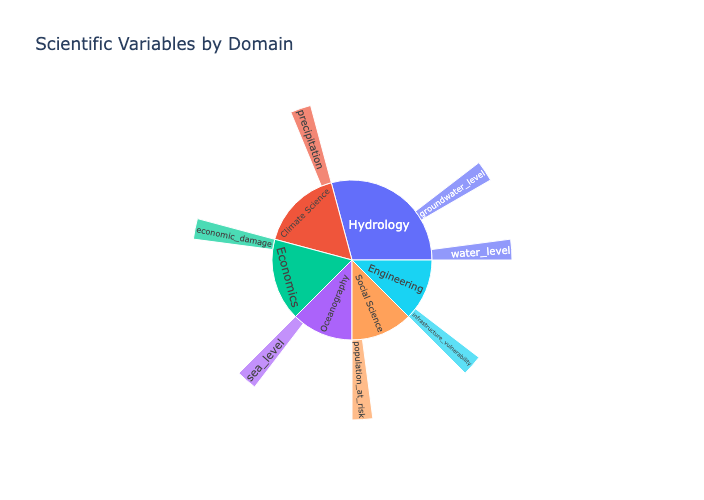

✓ Visualization complete!

Summary:
  Total semantic links: 24
  Domains covered: 6

  Links by domain:
    • Hydrology: 7
    • Climate Science: 4
    • Economics: 4
    • Oceanography: 3
    • Social Science: 3
    • Engineering: 3


In [22]:
# Visualize scientific-variable coverage by domain
_, sunburst_fig, domain_counts = plot_svo_sunburst(unique_mappings)
sunburst_fig.show()

print('✓ Visualization complete!')
print('\nSummary:')
print(f'  Total semantic links: {len(unique_mappings)}')
print(f'  Domains covered: {len(domain_counts)}')
print('\n  Links by domain:')
for domain, count in sorted(domain_counts.items(), key=lambda item: item[1], reverse=True):
    print(f'    • {domain}: {count}')


## Interpreting the Sunburst Figure

The **Scientific Variables by Domain** sunburst chart shows how stakeholder narratives connect to scientific concepts.

### What the figure shows

**Inner ring:** scientific domains such as Hydrology, Climate Science, Social Science, Economics, Engineering, and Oceanography

**Outer ring:** individual scientific variables nested within each domain, such as:
- `water_level` and `groundwater_level` under Hydrology
- `precipitation` under Climate Science  
- `economic_damage` under Economics
- `infrastructure_vulnerability` under Engineering

**Segment size:** proportional to how frequently each domain or variable appears in the mapped text

### What it tells you

1. **Problem scope:** which scientific disciplines are most relevant to the stakeholder concerns

2. **Data needs:** what kinds of measurements, datasets, or monitoring systems may support the decision process

3. **Interdisciplinary structure:** whether the problem is concentrated in one field or spread across several domains

4. **Stakeholder priorities:** which measurable concepts best reflect the language people use to describe the problem

### Why this matters for TACC workflows

This figure helps you identify:
- Which computational models you need (hydrological, economic, infrastructure assessment)
- What datasets to access from TACC resources or external sources
- Which scientific experts should be engaged
- How to structure your decision support system to match stakeholder mental models

In short, it shows which science is needed to answer the questions the community is asking.

## Step 7: Generate Summary Report

In the final step, the notebook writes a short report that summarizes the topics, mappings, decision components, and generated outputs.

In [23]:
# Export the main analysis outputs and write the summary report
output_files = write_outputs_table(
    OUTPUT_DIR,
    CASE_STUDY_NAME,
    topic_mappings,
    components_df,
    svo_df,
    network_fig,
    sunburst_fig,
)

summary = build_summary_report(
    CASE_STUDY_NAME,
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    unique_mappings,
    svo_df,
)
report_path = write_report(OUTPUT_DIR, CASE_STUDY_NAME, summary)

print('=' * 70)
print('SEMANTIC BRIDGE ANALYSIS COMPLETE')
print('=' * 70)
print('\nAnalysis Statistics:')
print(f'  • Documents Analyzed: {len(transcripts)}')
print(f'  • Topics Identified: {n_topics}')
print(f"  • Scientific Domains: {len(set(m['primary_domain'] for m in topic_mappings))}")
print(f'  • Decision Components: {sum(len(v) for v in decision_components.values())}')
print(f"  • Scientific Variables: {len(set(m['scientific_variable'] for m in unique_mappings))}")
print('\nOutput Files Generated:')
for path in output_files.values():
    print(f'  • {path.name}')
print(f'  • {report_path.name}')
print('\n' + '=' * 70)
print('✓ All files saved to outputs/')
print('=' * 70)


SEMANTIC BRIDGE ANALYSIS COMPLETE

Analysis Statistics:
  • Documents Analyzed: 11
  • Topics Identified: 5
  • Scientific Domains: 3
  • Decision Components: 50
  • Scientific Variables: 7

Output Files Generated:
  • community_analysis_topic_mappings.csv
  • community_analysis_components.csv
  • community_analysis_svo_mappings.csv
  • community_analysis_network.html
  • community_analysis_svo_sunburst.html
  • community_analysis_report.md

✓ All files saved to outputs/


In [24]:
# Preview the generated report
print('\nREPORT PREVIEW')
print('=' * 70)
print('\nFirst 1000 characters of generated report:\n')
print(summary[:1000])
print('\n...\n')
print(f'\n✓ Full report available at: {report_path}')



REPORT PREVIEW

First 1000 characters of generated report:

# Semantic Bridge Analysis Report

## community_analysis

**Generated:** 2026-04-15 13:36

---

## Analysis Summary

- **Documents Analyzed:** 11
- **Topics Identified:** 5
- **Scientific Domains:** 3
- **Decision Components:** 50
- **Scientific Variables:** 7

---

## Key Findings

### Topics Discovered

**Topic 1**
- Keywords: groundwater, regulatory, water, subsidence, said
- Primary Domain: Physical Science
- Secondary Domain: Environmental Science

**Topic 2**
- Keywords: water, infrastructure, new, implementation, city
- Primary Domain: Environmental Science
- Secondary Domain: Engineering

**Topic 3**
- Keywords: subsidence, houston, galveston, area, bay
- Primary Domain: Environmental Science
- Secondary Domain: Physical Science

**Topic 4**
- Keywords: center, term, area, long, development
- Primary Domain: Engineering

**Topic 5**
- Keywords: water, sand, infrastructure, alternative, future
- Primary Domain: Environ

In [25]:
# Create a compact reference table for the workflow outputs
quick_ref = build_quick_reference(
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    svo_vocabulary,
    unique_mappings,
    output_files,
)

print('\nQUICK REFERENCE SUMMARY')
print('=' * 70)
print(quick_ref.to_string(index=False))
print('=' * 70)

quick_ref_path = OUTPUT_DIR / f'{CASE_STUDY_NAME}_summary_table.csv'
quick_ref.to_csv(quick_ref_path, index=False)
print(f'\n✓ Saved quick reference: {quick_ref_path}')



QUICK REFERENCE SUMMARY
  Analysis Component  Count                           Output File
     Input Documents     11                                   N/A
   Topics Discovered      5 community_analysis_topic_mappings.csv
  Scientific Domains      3       community_analysis_network.html
 Decision Components     50     community_analysis_components.csv
Scientific Variables      7   community_analysis_svo_mappings.csv
      Semantic Links     24   community_analysis_svo_mappings.csv

✓ Saved quick reference: outputs/community_analysis_summary_table.csv


## Wrap-Up

You have completed the semantic bridge analysis workflow.

### What you learned
- How to extract topics from text automatically
- How to map narratives to scientific domains
- How to identify decision components
- How to link language to measurable variables

### How to apply this to your own work
1. Replace sample data with your own documents
2. Customize domains in `science_backbone`
3. Expand `svo_vocabulary`
4. Adjust the `n_topics` parameter
5. Re-run and validate with stakeholders

### Output files
All results are saved in the `outputs/` folder:
- CSV files for further analysis
- HTML visualizations for sharing
- Markdown report for documentation

### Next steps
- Review the generated outputs with domain experts and stakeholders
- Refine the science backbone and variable mappings for your domain
- Connect the results to downstream datasets, models, or decision tools

This workflow is designed to preserve stakeholder language while connecting it to scientific and engineering analysis.